In [20]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

In [21]:
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

In [24]:
X

array([[ 6.22519125e-01, -3.72101344e-01],
       [ 1.90426932e+00, -1.36302945e-01],
       [-6.94312816e-02,  4.56116985e-01],
       [ 9.33898633e-01,  2.37482827e-01],
       [ 1.18035952e+00, -4.90846917e-01],
       [ 1.02541488e+00, -4.62482874e-01],
       [ 4.11984697e-01, -2.85969715e-01],
       [-6.12663134e-01,  7.29788185e-01],
       [ 9.48145854e-01,  7.95791386e-02],
       [ 1.71242445e-01,  1.58374951e-03],
       [ 1.29201956e+00, -3.77322706e-01],
       [ 3.72211026e-01,  8.92249223e-01],
       [ 9.16250451e-01, -4.88055386e-01],
       [ 6.26278567e-01,  8.66028662e-01],
       [ 1.71157998e-01, -5.55663311e-02],
       [ 9.71527259e-01, -5.27473544e-01],
       [ 1.99307684e+00,  3.03573972e-01],
       [ 7.20383729e-01, -4.16166842e-01],
       [-9.27909913e-01,  2.14482709e-02],
       [ 1.16141211e-01,  2.38388568e-01],
       [-6.21140311e-02,  1.00608737e+00],
       [-7.83123575e-01,  6.13188694e-01],
       [ 1.50215227e+00, -4.12314518e-01],
       [ 1.

In [22]:
param_sets = [
    {'eps': 0.1, 'min_samples': 5, 'title': 'eps=0.1 (太小)'},
    {'eps': 0.2, 'min_samples': 5, 'title': 'eps=0.2 (合适)'},
    {'eps': 0.5, 'min_samples': 5, 'title': 'eps=0.5 (太大)'},
    {'eps': 0.2, 'min_samples': 3, 'title': 'min_samples=3 (太小)'},
    {'eps': 0.2, 'min_samples': 10, 'title': 'min_samples=10 (偏大)'},
    {'eps': 0.2, 'min_samples': 5, 'title': 'eps=0.2, min_samples=5 (基线)'},
]

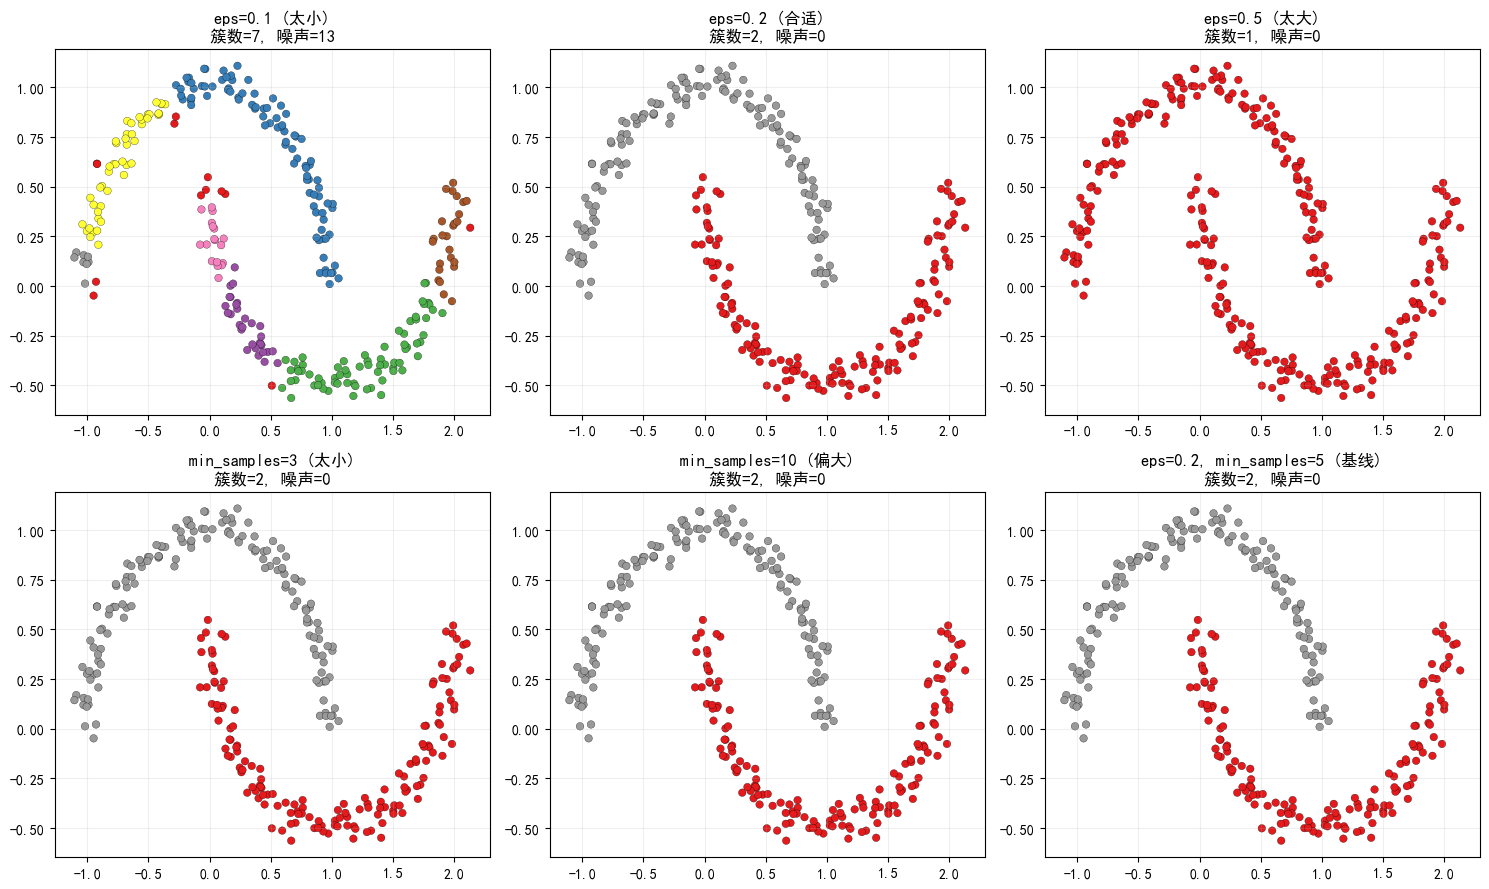

In [23]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, params in zip(axes.flat, param_sets):
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])

    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='Set1', s=30, edgecolor='k', linewidth=0.2)
    ax.set_title(f"{params['title']}\n簇数={n_clusters}, 噪声={n_noise}")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()